In [21]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

In [22]:
# Load dataset
df = pd.read_csv("ObesityDataSet.csv")

In [23]:
# Menangani missing value
print("Missing values sebelum:")
print(df.isnull().sum())

# Jika ada missing values, isi dengan mean (numerik) atau modus (kategorikal)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].mean(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values setelah:")
print(df.isnull().sum())

Missing values sebelum:
Age                               14
Gender                             9
Height                            12
Weight                            11
CALC                               5
FAVC                              11
FCVC                               8
NCP                               12
SCC                               10
SMOKE                              5
CH2O                               6
family_history_with_overweight    13
FAF                                8
TUE                                9
CAEC                              11
MTRANS                             6
NObeyesdad                         0
dtype: int64
Missing values setelah:
Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                   

<ipython-input-23-a94199b5bc28>:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [24]:
# Hitung jumlah duplikasi sebelum dihapus
dupes_before = df.duplicated().sum()
print(f"Jumlah duplikasi sebelum dihapus: {dupes_before}")

# Hapus duplikasi
df.drop_duplicates(inplace=True)

# Hitung jumlah duplikasi setelah dihapus
dupes_after = df.duplicated().sum()
print(f"Jumlah duplikasi setelah dihapus: {dupes_after}")

Jumlah duplikasi sebelum dihapus: 18
Jumlah duplikasi setelah dihapus: 0


In [31]:
# Tampilkan kolom bertipe object (kategori)
categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC',
                    'SMOKE', 'SCC', 'CALC', 'MTRANS']
target_col = 'NObeyesdad'

# Encode kategori dan target
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df[target_col] = le.fit_transform(df[target_col].astype(str))

# Validasi hasil
print("Contoh data setelah encoding:")
print(df.head())

Contoh data setelah encoding:
  Age  Gender Height Weight  CALC  FAVC FCVC NCP  SCC  SMOKE CH2O  \
0  21       1   1.62     64     4     1    2   3    1      1    2   
1  21       1   1.52     56     3     1    3   3    2      2    3   
2  23       2    1.8     77     2     1    2   3    1      1    2   
3  27       2    1.8     87     2     1    3   3    1      1    2   
4  22       2   1.78   89.8     3     1    2   1    1      1    2   

   family_history_with_overweight FAF TUE  CAEC  MTRANS  NObeyesdad  
0                               2   0   1     3       4           1  
1                               2   3   0     3       4           1  
2                               2   2   1     3       4           1  
3                               1   2   0     3       5           5  
4                               1   0   0     3       4           6  


In [33]:
# Pastikan kolom numerik bertipe numeric
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # Isi NaN setelah konversi dengan modus
    if df[col].isnull().sum() > 0:
        mode = df[col].mode()[0]
        df[col].fillna(mode, inplace=True)

<ipython-input-33-3218d36286ab>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode, inplace=True)


In [34]:
# Tangani outlier pada kolom numerik
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Ganti outlier dengan modus
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    if outlier_count > 0:
        mode = df[col].mode()[0]
        df[col] = np.where((df[col] < lower_bound) | (df[col] > upper_bound), mode, df[col])
        print(f"{col}: {outlier_count} outlier diganti dengan modus ({mode})")
    else:
        print(f"{col}: tidak ditemukan outlier")

Age: 176 outlier diganti dengan modus (18.0)
Height: 11 outlier diganti dengan modus (1.7)
Weight: 15 outlier diganti dengan modus (80.0)
FCVC: 8 outlier diganti dengan modus (3.0)
NCP: 599 outlier diganti dengan modus (3.0)
CH2O: 8 outlier diganti dengan modus (2.0)
FAF: 13 outlier diganti dengan modus (0.0)
TUE: 7 outlier diganti dengan modus (0.0)


In [35]:
# Split data menjadi fitur dan target
X = df.drop(columns=[target_col])
y = df[target_col]

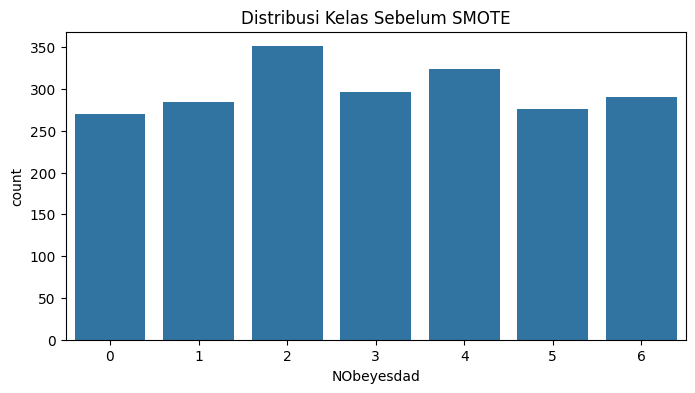

In [36]:
# Tampilkan distribusi kelas sebelum SMOTE
plt.figure(figsize=(8,4))
sns.countplot(x=y)
plt.title("Distribusi Kelas Sebelum SMOTE")
plt.show()

In [37]:
# Split train-test set terlebih dahulu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

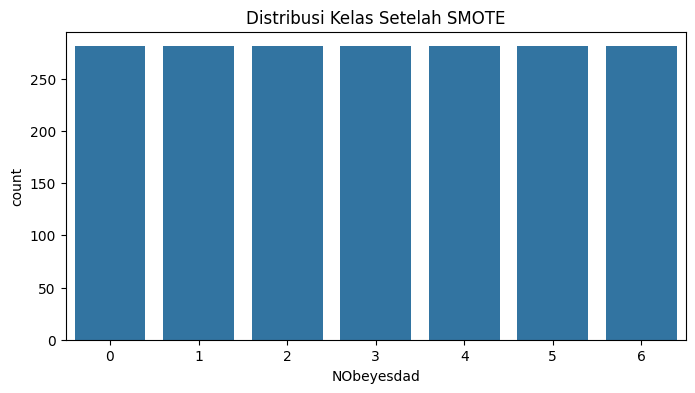

In [39]:
# Terapkan SMOTE untuk mengatasi ketidakseimbangan kelas
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Tampilkan distribusi kelas sesudah SMOTE
plt.figure(figsize=(8,4))
sns.countplot(x=y_resampled)
plt.title("Distribusi Kelas Setelah SMOTE")
plt.show()

In [40]:
# Standarisasi fitur
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

In [41]:
# Tampilkan bentuk akhir data
print("Shape X_train (resampled, scaled):", X_resampled_scaled.shape)
print("Shape y_train (resampled):", y_resampled.shape)
print("Shape X_test (scaled):", X_test_scaled.shape)
print("Shape y_test:", y_test.shape)

Shape X_train (resampled, scaled): (1967, 16)
Shape y_train (resampled): (1967,)
Shape X_test (scaled): (419, 16)
Shape y_test: (419,)


Kesimpulan

Penanganan Missing Values
Semua missing values pada dataset berhasil diisi dengan metode:
- Nilai numerik diisi dengan rata-rata (mean) kolom tersebut.
- Nilai kategorikal diisi dengan modus (nilai yang paling sering muncul).

Penghapusan Data Duplikat
Data yang duplikat dihapus untuk menghindari bias pada model dan menjaga kualitas data. Ini memastikan setiap data unik dan informasi yang diberikan tidak berulang.

Transformasi Data Kategori ke Numerik
Semua kolom kategori berhasil diubah menjadi format numerik menggunakan Label Encoding, sehingga data siap digunakan untuk algoritma machine learning yang biasanya hanya menerima input numerik.

Deteksi dan Penanganan Outlier
Outlier pada kolom numerik diidentifikasi menggunakan metode IQR dan diganti dengan nilai modus kolom masing-masing.